In [80]:
import sys
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import fft, fftfreq

PROJECT_PATH = Path("C:/Users/Архиповы/source/repos/modem") #путь к файлу txt
sys.path.insert(0, str(PROJECT_PATH / "src"))

from modem.blocks import MessageSource, StringToBits, PacketBuileder, PCM, BPSK, HammingDecoder, HammongEncoder
from modem.blocks import BFSK, Channel, BFSKDemodulator, PacketDecoder, Demodulator, BitsToString
from modem.pipeline import run


In [81]:
def calculate_ber(original_bits, recovered_bits):
    min_len = min(len(original_bits), len(recovered_bits))
    if min_len == 0:
        return 1.0
    errors = np.sum(original_bits[:min_len] != recovered_bits[:min_len])
    return errors / min_len


In [85]:
#  Режим работы 
USE_BPSK = 0   # 1 = BPSK, 0 = BFSK

# Параметры передачи
freq_carrier = 1000      # Частота несущей
R_b = 100               # Битовая скорость 
snr_db = 40             # SNR 
k = 0.85                # Затухание
use_hamming = 1         # 1 = использовать код Хэмминга, 0 = нет
filepath = "C:/Users/Архиповы/Desktop/Попытка эволюции/message_source.txt"
default_text = "Hello DSP"


In [86]:
samp_rate = freq_carrier * 20
samp_per_bit = int(samp_rate / R_b)
h = 1.0
f0 = freq_carrier - R_b * h
f1 = freq_carrier + R_b * h



In [72]:
ctx = {}              # запускать только при bpsk!!!!
capture = {}

blocks = [
    MessageSource(filepath=filepath, default_text=default_text, name="MS"),
    StringToBits(encoding='utf-8', name="StB"),
]

if use_hamming:
    blocks.append(HammongEncoder(name="HE"))

blocks.append(PacketBuileder(preamble="1010101010101010", sfd="10101011", add_crc=True, name="packet"))
blocks.append(PCM(name="PCM"))
blocks.append(BPSK(freq_carrier=freq_carrier, R_b=R_b, name="bpsk"))
blocks.append(Channel(k=k, snr_db=snr_db, name="channel"))
blocks.append(Demodulator(freq_carrier=freq_carrier, samp_rate=samp_rate, R_b=R_b, lpf_cutoff_multiplier=1.5, name="demod"))

if use_hamming:
    blocks.append(HammingDecoder(name="HammDecoder"))

blocks.append(PacketDecoder(preamble="1010101010101010", sfd="10101011", name="PackDec"))
blocks.append(BitsToString(encoding='utf-8', name="BSt"))
result = run(blocks, x=None, ctx=ctx, capture=capture)
original_text = ctx.get("source_message", capture.get("MS", "???"))
decoded_text = ctx.get("decoded_text", capture.get("BSt", "???"))
original_bits = ctx.get("bits", capture.get("StB", []))
recovered_bits = ctx.get("bpsk_demod", capture.get("demod", []))

ber = calculate_ber(original_bits, recovered_bits)
nrz_signal = ctx.get("NRZ_signal", capture.get("PCM", []))
mod_signal = ctx.get("BPSK_signal", capture.get("bpsk", []))
channel_out = ctx.get("channel_output", capture.get("channel", []))
before_lpf = ctx.get("before_LPF", [])
after_lpf = ctx.get("after_LPF", [])
print(f"BER: {ber:.8f}"
      
MAX_DISPLAY_BITS = 30
MAX_DISPLAY_SAMPLES = 2000

if len(nrz_signal) > 0:
    plt.figure(figsize=(12, 4))
    n_show = min(len(nrz_signal), MAX_DISPLAY_BITS)
    t_bits = np.arange(n_show) * (samp_per_bit / samp_rate)
    plt.step(t_bits, nrz_signal[:n_show], where='post')
    plt.xlabel("Time, sec")
    plt.ylabel("Amplitude")
    plt.grid(True, alpha=0.3)
    plt.title(f"NRZ сигнал")
    plt.ylim(-1.5, 1.5)
    plt.tight_layout()
    plt.show()
else:
    print("Нет NRZ сигнала")
if len(mod_signal) > 0:
    plt.figure(figsize=(12, 4))
    n_show = min(len(mod_signal), MAX_DISPLAY_SAMPLES)
    t = np.arange(n_show) / samp_rate
    plt.plot(t, mod_signal[:n_show])
    plt.xlabel("Time, sec")
    plt.ylabel("Amplitude")
    plt.grid(True, alpha=0.3)
    plt.title("BPSK модулированный сигнал")
    plt.tight_layout()
    plt.show()
else:
    print("Нет BPSK сигнала")
if len(mod_signal) > 0 and len(channel_out) > 0:
    plt.figure(figsize=(12, 4))
    n_show = min(len(mod_signal), MAX_DISPLAY_SAMPLES)
    t = np.arange(n_show) / samp_rate
    plt.plot(t, mod_signal[:n_show], label='Вход канала')
    plt.plot(t, channel_out[:n_show], label='Выход канала')
    plt.xlabel("Time, sec")
    plt.ylabel("Amplitude")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.title("Канал связи")
    plt.tight_layout()
    plt.show()
else:
    print("Нет данных для канала")

if len(before_lpf) > 0 and len(after_lpf) > 0:
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 6))
    n_show = min(len(before_lpf), 1000)
    t = np.arange(n_show) / samp_rate
    ax1.plot(t, before_lpf[:n_show])
    ax1.set_title("Сигнал ДО ФНЧ")
    ax1.set_ylabel("Амплитуда")
    ax1.grid(True, alpha=0.3)
    ax2.plot(t, after_lpf[:n_show])
    ax2.set_title("Сигнал после ФНЧ")
    ax2.set_xlabel("Time, sec")
    ax2.set_ylabel("Амплитуда")
    ax2.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

if len(recovered_bits) > 0:
    plt.figure(figsize=(12, 4))
    n_show = min(len(recovered_bits), MAX_DISPLAY_BITS)
    t_bits = np.arange(n_show) * (samp_per_bit / samp_rate)
    plt.step(t_bits, recovered_bits[:n_show], where='post')
    plt.xlabel("Time, sec")
    plt.ylabel("Amplitude")
    plt.grid(True, alpha=0.3)
    plt.title(f"Демодулированные биты (первые {n_show})")
    plt.ylim(-0.2, 1.2)
    plt.tight_layout()
    plt.show()
else:
    print("Нет демодулированных битов")

The text from the file C:\Users\Архиповы\Desktop\Попытка эволюции\message_source.txt was successfully recived
Отправлено: Blah - blah - blah - blah - blah - blah - blah - blah - blah - blah - blah - blah - blah - blah - bl
Получено:   ̃̃̃̃̃̃̃̃̃̃̃̃̃̃̃̃̃̃̃̃̃̃̃̃̃̃̃̃̃̃̃̃̃̃̃̃̃̃̃̃̃̃̃̃̃̃̃̃̃̃̃̃̃̃̃̃̃̃̃̃̃̃̃̃̃̃̃̃̃̃̃̃̃̃̃̃̃̃̃̃̃̃̃N"̌71
BER: 0.00000000


The text from the file C:\Users\Архиповы\Desktop\Попытка эволюции\message_source.txt was successfully recived
BER: 0.12517273


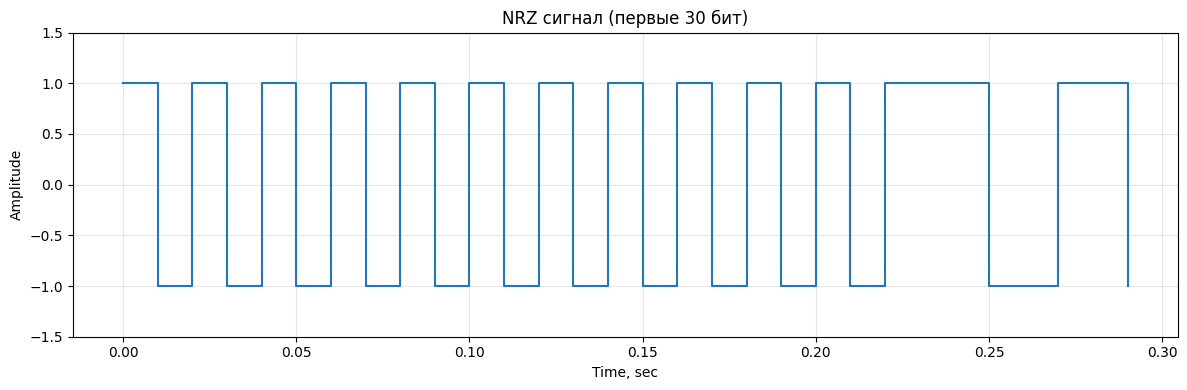

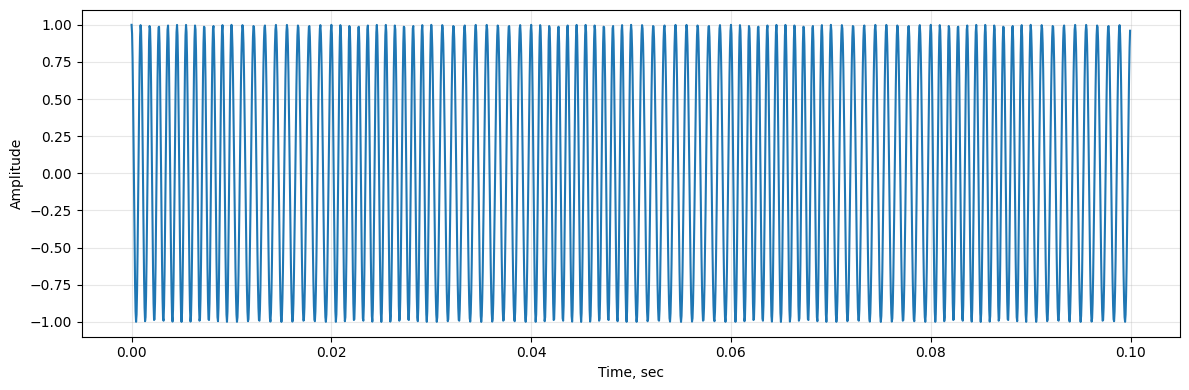

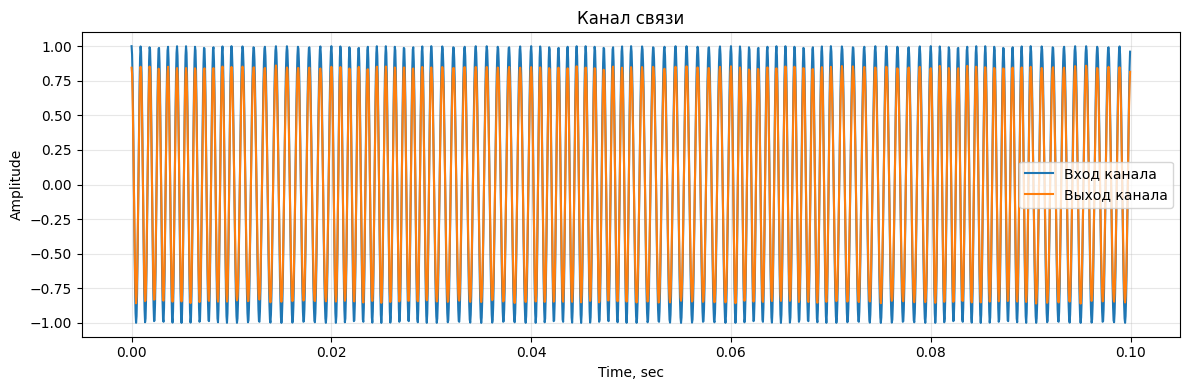

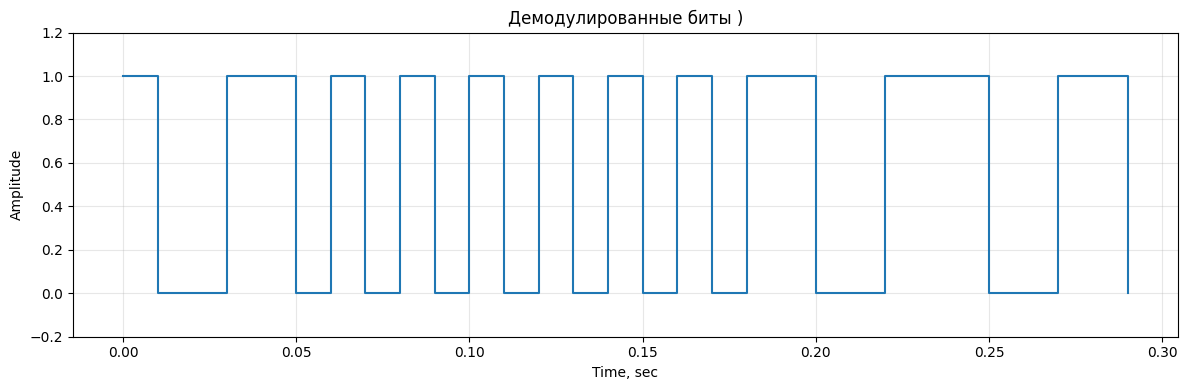

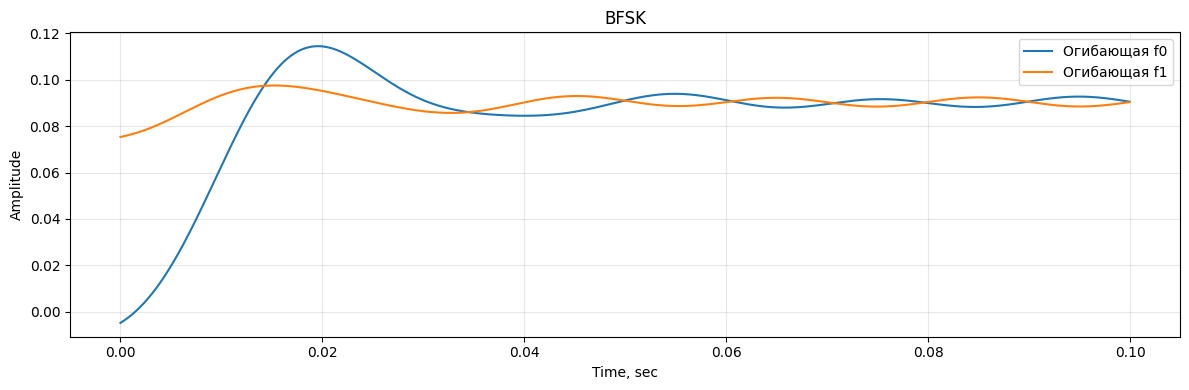

In [87]:
h = 1.0                # запускать только при bfsk!!!!
f0 = freq_carrier - R_b * h
f1 = freq_carrier + R_b * h
ctx = {}
capture = {}

blocks = [
    MessageSource(filepath=filepath, default_text=default_text, name="MS"),
    StringToBits(encoding='utf-8', name="StB"),
]

if use_hamming:
    blocks.append(HammongEncoder(name="HE"))

blocks.append(PacketBuileder(preamble="1010101010101010", sfd="10101011", add_crc=True, name="packet"))
blocks.append(PCM(name="PCM"))
blocks.append(BFSK(freq_carrier=freq_carrier, R_b=R_b, h=h, name="BFSK"))
blocks.append(Channel(k=k, snr_db=snr_db, name="channel"))
blocks.append(BFSKDemodulator(f0=f0, f1=f1, samp_rate=samp_rate, samp_per_bit=samp_per_bit, name="BFSKDM"))

if use_hamming:
    blocks.append(HammingDecoder(name="HammDecoder"))

blocks.append(PacketDecoder(preamble="1010101010101010", sfd="10101011", name="PackDec"))
blocks.append(BitsToString(encoding='utf-8', name="BSt"))
result = run(blocks, x=None, ctx=ctx, capture=capture)
original_text = ctx.get("source_message", capture.get("MS", "???"))
decoded_text = ctx.get("decoded_text", capture.get("BSt", "???"))
original_bits = ctx.get("bits", capture.get("StB", []))
recovered_bits = ctx.get("bfsk_demod", capture.get("BFSKDM", []))

ber = calculate_ber(original_bits, recovered_bits)
print(f"BER: {ber:.8f}")
nrz_signal = ctx.get("NRZ_signal", capture.get("PCM", []))
mod_signal = ctx.get("BFSK_signal_good", capture.get("BFSK", []))
channel_out = ctx.get("channel_output", capture.get("channel", []))
envelope0 = ctx.get("bfsk_envelope0", [])
envelope1 = ctx.get("bfsk_envelope1", [])
after_bpf0 = ctx.get("bfsk_after_bpf0", [])
after_bpf1 = ctx.get("bfsk_after_bpf1", [])

MAX_DISPLAY_BITS = 30
MAX_DISPLAY_SAMPLES = 2000

if len(nrz_signal) > 0:
    plt.figure(figsize=(12, 4))
    n_show = min(len(nrz_signal), MAX_DISPLAY_BITS)
    t_bits = np.arange(n_show) * (samp_per_bit / samp_rate)
    plt.step(t_bits, nrz_signal[:n_show], where='post')
    plt.xlabel("Time, sec")
    plt.ylabel("Amplitude")
    plt.grid(True, alpha=0.3)
    plt.title(f"NRZ сигнал ")
    plt.ylim(-1.5, 1.5)
    plt.tight_layout()
    plt.show()
if len(mod_signal) > 0:
    plt.figure(figsize=(12, 4))
    n_show = min(len(mod_signal), MAX_DISPLAY_SAMPLES)
    t = np.arange(n_show) / samp_rate
    plt.plot(t, mod_signal[:n_show])
    plt.xlabel("Time, sec")
    plt.ylabel("Amplitude")
    plt.grid(True, alpha=0.3)
    plt.title
    plt.tight_layout()
    plt.show()
# График 3: Канал
if len(mod_signal) > 0 and len(channel_out) > 0:
    plt.figure(figsize=(12, 4))
    n_show = min(len(mod_signal), MAX_DISPLAY_SAMPLES)
    t = np.arange(n_show) / samp_rate
    plt.plot(t, mod_signal[:n_show], label='Вход канала')
    plt.plot(t, channel_out[:n_show], label='Выход канала')
    plt.xlabel("Time, sec")
    plt.ylabel("Amplitude")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.title("Канал связи")
    plt.tight_layout()
    plt.show()

if len(recovered_bits) > 0:
    plt.figure(figsize=(12, 4))
    n_show = min(len(recovered_bits), MAX_DISPLAY_BITS)
    t_bits = np.arange(n_show) * (samp_per_bit / samp_rate)
    plt.step(t_bits, recovered_bits[:n_show], where='post', linewidth=1.5)
    plt.xlabel("Time, sec")
    plt.ylabel("Amplitude")
    plt.grid(True, alpha=0.3)
    plt.title(f"Демодулированные биты ")
    plt.ylim(-0.2, 1.2)
    plt.tight_layout()
    plt.show()


if len(envelope0) > 0 and len(envelope1) > 0:
    plt.figure(figsize=(12, 4))
    n_show = min(len(envelope0), MAX_DISPLAY_SAMPLES)
    t = np.arange(n_show) / samp_rate
    plt.plot(t, envelope0[:n_show], label='Огибающая f0')
    plt.plot(t, envelope1[:n_show], label='Огибающая f1')
    plt.xlabel("Time, sec")
    plt.ylabel("Amplitude")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.title("BFSK")
    plt.tight_layout()
    plt.show()
